# Métricas para Clasificación Multiclase
### Dataset: Bike Sharing — UCI (hour.csv)

En este cuadernillo aplicamos las métricas de clasificación multiclase al dataset **Bike Sharing (hour.csv)**.
La variable original `cnt` (total de bicicletas alquiladas por hora) se convierte en **3 clases de demanda**:
- **Clase 0 — Demanda BAJA:** cnt < 100
- **Clase 1 — Demanda MEDIA:** 100 ≤ cnt < 300
- **Clase 2 — Demanda ALTA:** cnt ≥ 300

Veremos las métricas más importantes adaptadas a clasificación multiclase: *Accuracy*, Matriz de Confusión, *Precision*, *Recall*, *F1-Score* y comparación de modelos.

## 1. Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    classification_report
)

%matplotlib inline
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. El Dataset Bike Sharing

El dataset **Bike Sharing** del UCI contiene **17,379 registros** de alquiler de bicicletas por hora en Washington D.C. durante 2011 y 2012.
Tiene **13 features** sobre clima, temporada y tiempo que usamos para predecir el nivel de demanda.

In [2]:
data = pd.read_csv('hour.csv')

print("Dataset cargado correctamente.")
print("Dimensiones:", data.shape)
print()
display(data.head())

Dataset cargado correctamente.
Dimensiones: (17379, 17)



,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 3. Exploración del Dataset

In [3]:
print("Columnas disponibles:")
print(data.columns.tolist())
print()
print("Tipos de datos:")
print(data.dtypes)
print()
print("Estadísticas de la variable cnt:")
print(data['cnt'].describe())

Columnas disponibles:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Tipos de datos:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Estadísticas de la variable cnt:
count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64


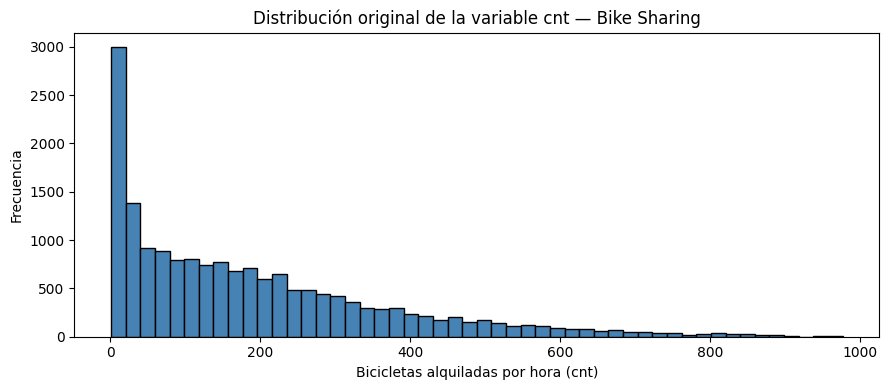

In [4]:
plt.figure(figsize=(9, 4))
plt.hist(data['cnt'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel("Bicicletas alquiladas por hora (cnt)")
plt.ylabel("Frecuencia")
plt.title("Distribución original de la variable cnt — Bike Sharing")
plt.tight_layout()
plt.show()

## 4. Creación de la Variable Multiclase

Convertimos `cnt` en 3 clases de demanda usando percentiles para balancear las clases.

In [5]:
def asignar_clase(cnt):
    if cnt < 100:
        return 0   # Demanda BAJA
    elif cnt < 300:
        return 1   # Demanda MEDIA
    else:
        return 2   # Demanda ALTA

data['demanda'] = data['cnt'].apply(asignar_clase)

print("Distribución de clases de demanda:")
conteo = data['demanda'].value_counts().sort_index()
for clase, cantidad in conteo.items():
    nombre = ['BAJA (0)', 'MEDIA (1)', 'ALTA (2)'][clase]
    pct = cantidad / len(data) * 100
    print(f"  Clase {nombre}: {cantidad:,} registros ({pct:.1f}%)")

Distribución de clases de demanda:
  Clase BAJA (0): 7,010 registros (40.3%)
  Clase MEDIA (1): 6,448 registros (37.1%)
  Clase ALTA (2): 3,921 registros (22.6%)


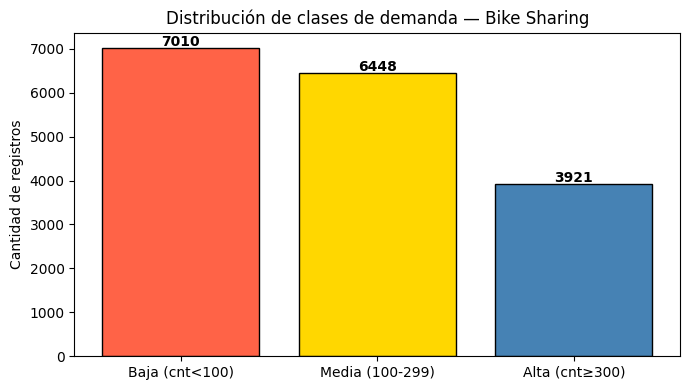

In [6]:
plt.figure(figsize=(7, 4))
nombres = ['Baja (cnt<100)', 'Media (100-299)', 'Alta (cnt≥300)']
colores = ['tomato', 'gold', 'steelblue']
conteos = [data['demanda'].value_counts()[i] for i in range(3)]

barras = plt.bar(nombres, conteos, color=colores, edgecolor='black')
plt.title("Distribución de clases de demanda — Bike Sharing")
plt.ylabel("Cantidad de registros")
for bar, val in zip(barras, conteos):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Preparación de Datos

In [7]:
# Descartamos columnas no predictivas
# instant: índice, dteday: fecha texto, casual/registered: componen cnt, cnt: variable original
features = [
    'season',      # temporada 1-4
    'yr',          # año 0=2011, 1=2012
    'mnth',        # mes 1-12
    'hr',          # hora del día 0-23
    'holiday',     # día festivo
    'weekday',     # día de la semana
    'workingday',  # día laboral
    'weathersit',  # situación climática 1-4
    'temp',        # temperatura normalizada
    'atemp',       # sensación térmica normalizada
    'hum',         # humedad normalizada
    'windspeed',   # velocidad del viento normalizada
]

X = data[features].values.astype(np.float64)
y = data['demanda'].values.astype(np.int32)

print(f"Features usadas: {len(features)}")
print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Clases únicas: {np.unique(y)}")

Features usadas: 12
Forma de X: (17379, 12)
Forma de y: (17379,)
Clases únicas: [0 1 2]


In [8]:
# Normalización
def normalizar(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    return (X - mu) / sigma, mu, sigma

X_norm, mu, sigma = normalizar(X)

# División 75/25
split = int(len(X_norm) * 0.75)

X_train, X_test = X_norm[:split], X_norm[split:]
y_train, y_test = y[:split],      y[split:]

print(f"Entrenamiento: {X_train.shape[0]:,} muestras (75%)")
print(f"Prueba:        {X_test.shape[0]:,} muestras  (25%)")

Entrenamiento: 13,034 muestras (75%)
Prueba:        4,345 muestras  (25%)


## 6. Modelo — Regresión Logística One-vs-All

Para clasificación multiclase usamos el esquema **One-vs-All**: entrenamos un clasificador binario por cada clase.
- Clasificador 0: ¿Es demanda BAJA o no?
- Clasificador 1: ¿Es demanda MEDIA o no?
- Clasificador 2: ¿Es demanda ALTA o no?

In [9]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = (1/m) * (-y.dot(np.log(h)) - (1-y).dot(np.log(1 - h)))
    J += (lambda_ / (2*m)) * np.sum(theta[1:]**2)
    grad = (1/m) * X.T.dot(h - y)
    grad[1:] += (lambda_ / m) * theta[1:]
    return J, grad

def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n))
    costos = []
    for k in range(num_labels):
        print(f"  Entrenando clase {k}...")
        y_bin = (y == k).astype(int)
        theta_init = np.zeros(n)
        result = optimize.minimize(
            lrCostFunction,
            theta_init,
            args=(X, y_bin, lambda_),
            method='TNC',
            jac=True,
            options={'maxiter': 300}
        )
        all_theta[k] = result.x
        costos.append(result.fun)
        print(f"    Costo final: {result.fun:.6f}")
    return all_theta, costos

def predictOneVsAll(all_theta, X):
    probs = sigmoid(X.dot(all_theta.T))
    return np.argmax(probs, axis=1)

X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b  = np.c_[np.ones(X_test.shape[0]),  X_test]

print("Entrenando modelo One-vs-All...")
all_theta, costos_finales = oneVsAll(X_train_b, y_train, 3, 0.01)

Entrenando modelo One-vs-All...
  Entrenando clase 0...
    Costo final: 0.449127
  Entrenando clase 1...
    Costo final: 0.596358
  Entrenando clase 2...
    Costo final: 0.373329


C:\Users\erick\AppData\Local\Temp\ipykernel_20312\1022521832.py:22: OptimizeWarning: Unknown solver options: maxiter
  result = optimize.minimize(


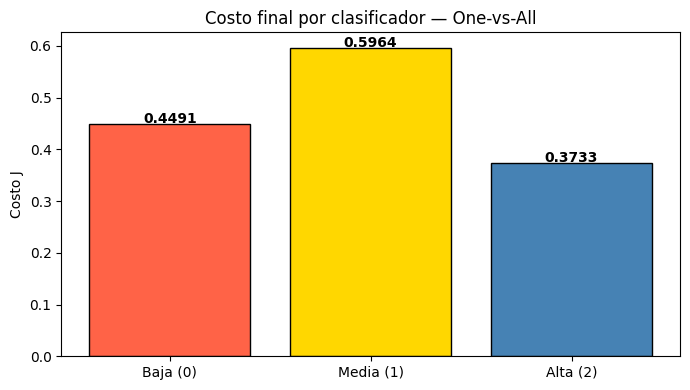

In [10]:
# Gráfica de costo por clasificador
plt.figure(figsize=(7, 4))
nombres_clases = ['Baja (0)', 'Media (1)', 'Alta (2)']
plt.bar(nombres_clases, costos_finales,
        color=['tomato', 'gold', 'steelblue'], edgecolor='black')
plt.title("Costo final por clasificador — One-vs-All")
plt.ylabel("Costo J")
for i, v in enumerate(costos_finales):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Predicciones

In [11]:
y_pred_train = predictOneVsAll(all_theta, X_train_b)
y_pred_test  = predictOneVsAll(all_theta, X_test_b)

print(f"Predicciones en entrenamiento realizadas: {len(y_pred_train):,}")
print(f"Predicciones en prueba realizadas:        {len(y_pred_test):,}")

Predicciones en entrenamiento realizadas: 13,034
Predicciones en prueba realizadas:        4,345


## 8. Accuracy

En multiclase la *accuracy* funciona igual que en binario: cuenta todas las predicciones correctas dividido el total.

$$ accuracy = \frac{\text{predicciones correctas}}{\text{total de ejemplos}} $$

In [12]:
def accuracy(y_pred, y):
    return np.sum(y_pred == y) / len(y)

acc_train = accuracy(y_pred_train, y_train)
acc_test  = accuracy(y_pred_test,  y_test)

print(f"Accuracy entrenamiento: {acc_train*100:.2f}%")
print(f"Accuracy prueba:        {acc_test*100:.2f}%")
print()
# Baseline: modelo naive que predice siempre la clase mayoritaria
clase_mayoritaria = np.bincount(y_train).argmax()
naive_acc = np.mean(y_test == clase_mayoritaria)
print(f"Baseline naive (clase {clase_mayoritaria} siempre): {naive_acc*100:.1f}%")
print(f"Nuestro modelo supera el baseline: {acc_test > naive_acc}")
print()
print("Accuracy sklearn:", accuracy_score(y_test, y_pred_test))

Accuracy entrenamiento: 65.11%
Accuracy prueba:        59.33%

Baseline naive (clase 0 siempre): 30.7%
Nuestro modelo supera el baseline: True

Accuracy sklearn: 0.593325661680092


## 9. Matriz de Confusión Multiclase

En multiclase la matriz de confusión es de **3×3**. La diagonal principal son las predicciones correctas y fuera de la diagonal están los errores (confusiones entre clases).

In [13]:
cm = confusion_matrix(y_test, y_pred_test)

print("Matriz de Confusión (3x3):")
print(cm)
print()
print("Interpretación:")
print(f"  Baja predicha como Baja:  {cm[0,0]:,}")
print(f"  Baja predicha como Media: {cm[0,1]:,}")
print(f"  Baja predicha como Alta:  {cm[0,2]:,}")
print(f"  Media predicha como Baja: {cm[1,0]:,}")
print(f"  Media predicha como Media:{cm[1,1]:,}")
print(f"  Media predicha como Alta: {cm[1,2]:,}")
print(f"  Alta predicha como Baja:  {cm[2,0]:,}")
print(f"  Alta predicha como Media: {cm[2,1]:,}")
print(f"  Alta predicha como Alta:  {cm[2,2]:,}")

Matriz de Confusión (3x3):
[[979 163 191]
 [236 676 586]
 [100 491 923]]

Interpretación:
  Baja predicha como Baja:  979
  Baja predicha como Media: 163
  Baja predicha como Alta:  191
  Media predicha como Baja: 236
  Media predicha como Media:676
  Media predicha como Alta: 586
  Alta predicha como Baja:  100
  Alta predicha como Media: 491
  Alta predicha como Alta:  923


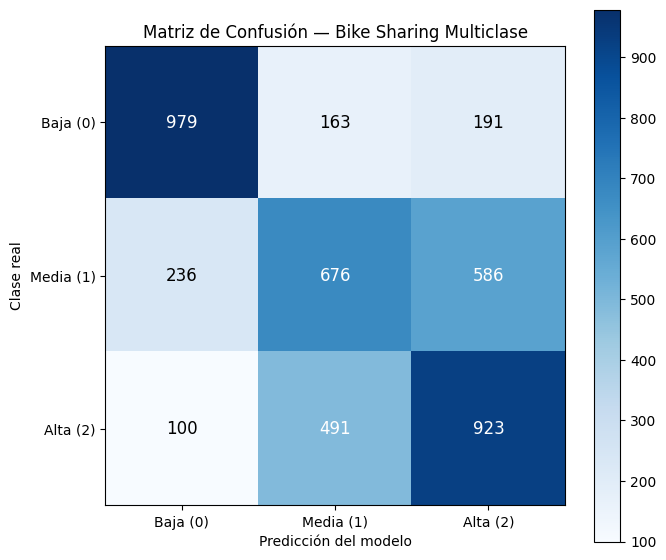

In [14]:
nombres = ['Baja (0)', 'Media (1)', 'Alta (2)']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1,2]); ax.set_xticklabels(nombres)
ax.set_yticks([0,1,2]); ax.set_yticklabels(nombres)
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de Confusión — Bike Sharing Multiclase")
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Precision, Recall y F1-Score por Clase

En multiclase calculamos estas métricas **para cada clase por separado** usando el esquema One-vs-Rest.

- **Precision por clase:** de todos los que predije como clase X, ¿cuántos realmente eran clase X?
- **Recall por clase:** de todos los que realmente eran clase X, ¿cuántos detecté correctamente?
- **F1 por clase:** balance entre precision y recall de esa clase

In [15]:
p_macro = precision_score(y_test, y_pred_test, average='macro')
r_macro = recall_score(y_test,   y_pred_test, average='macro')
f_macro = f1_score(y_test,       y_pred_test, average='macro')

p_weighted = precision_score(y_test, y_pred_test, average='weighted')
r_weighted = recall_score(y_test,   y_pred_test, average='weighted')
f_weighted = f1_score(y_test,       y_pred_test, average='weighted')

print("Métricas por clase:")
print(classification_report(
    y_test, y_pred_test,
    target_names=['Baja (0)', 'Media (1)', 'Alta (2)']
))
print(f"Macro    — Precision: {p_macro:.4f} | Recall: {r_macro:.4f} | F1: {f_macro:.4f}")
print(f"Weighted — Precision: {p_weighted:.4f} | Recall: {r_weighted:.4f} | F1: {f_weighted:.4f}")

Métricas por clase:
              precision    recall  f1-score   support

    Baja (0)       0.74      0.73      0.74      1333
   Media (1)       0.51      0.45      0.48      1498
    Alta (2)       0.54      0.61      0.57      1514

    accuracy                           0.59      4345
   macro avg       0.60      0.60      0.60      4345
weighted avg       0.59      0.59      0.59      4345

Macro    — Precision: 0.5986 | Recall: 0.5984 | F1: 0.5973
Weighted — Precision: 0.5928 | Recall: 0.5933 | F1: 0.5918


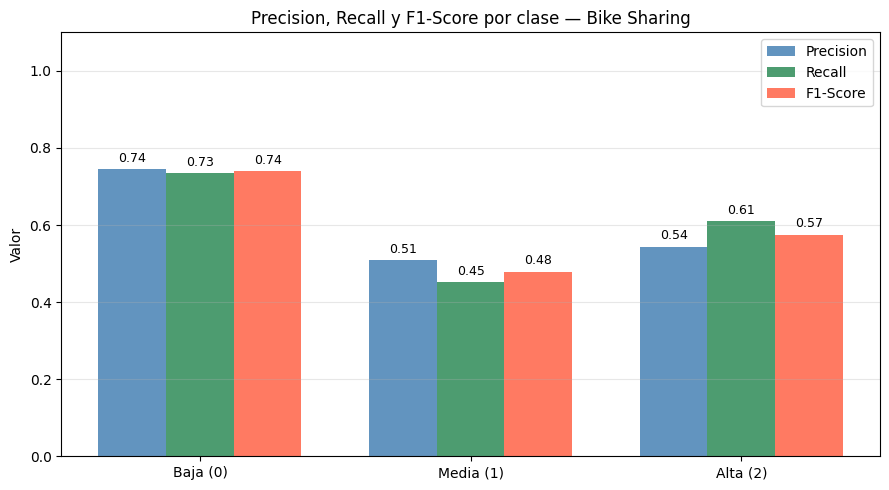

In [16]:
# Gráfica comparativa de métricas por clase
p_por_clase = precision_score(y_test, y_pred_test, average=None)
r_por_clase = recall_score(y_test,   y_pred_test, average=None)
f_por_clase = f1_score(y_test,       y_pred_test, average=None)

x = np.arange(3)
ancho = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - ancho, p_por_clase, ancho, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(x,         r_por_clase, ancho, label='Recall',    color='seagreen',   alpha=0.85)
ax.bar(x + ancho, f_por_clase, ancho, label='F1-Score',  color='tomato',     alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(['Baja (0)', 'Media (1)', 'Alta (2)'])
ax.set_ylabel("Valor")
ax.set_title("Precision, Recall y F1-Score por clase — Bike Sharing")
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
for i in range(3):
    ax.text(i - ancho, p_por_clase[i] + 0.02, f'{p_por_clase[i]:.2f}', ha='center', fontsize=9)
    ax.text(i,         r_por_clase[i] + 0.02, f'{r_por_clase[i]:.2f}', ha='center', fontsize=9)
    ax.text(i + ancho, f_por_clase[i] + 0.02, f'{f_por_clase[i]:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Accuracy vs Threshold por clase

Analizamos cómo varía el accuracy al cambiar el umbral de confianza mínima para cada clase.

In [17]:
thresholds = np.linspace(0.1, 0.9, 15)
accuracies = []

X_test_proba = sigmoid(X_test_b.dot(all_theta.T))

for t in thresholds:
    pred_t = np.full(len(X_test), -1, dtype=int)
    max_proba = X_test_proba.max(axis=1)
    pred_t[max_proba >= t] = np.argmax(X_test_proba[max_proba >= t], axis=1)
    # Para los que no superan el umbral asignamos la clase más probable
    pred_t[pred_t == -1] = np.argmax(X_test_proba[pred_t == -1], axis=1)
    accuracies.append(accuracy_score(y_test, pred_t))
    print(f"Threshold: {t:.2f} | Accuracy: {accuracies[-1]*100:.2f}%")

Threshold: 0.10 | Accuracy: 59.33%
Threshold: 0.16 | Accuracy: 59.33%
Threshold: 0.21 | Accuracy: 59.33%
Threshold: 0.27 | Accuracy: 59.33%
Threshold: 0.33 | Accuracy: 59.33%
Threshold: 0.39 | Accuracy: 59.33%
Threshold: 0.44 | Accuracy: 59.33%
Threshold: 0.50 | Accuracy: 59.33%
Threshold: 0.56 | Accuracy: 59.33%
Threshold: 0.61 | Accuracy: 59.33%
Threshold: 0.67 | Accuracy: 59.33%
Threshold: 0.73 | Accuracy: 59.33%
Threshold: 0.79 | Accuracy: 59.33%
Threshold: 0.84 | Accuracy: 59.33%
Threshold: 0.90 | Accuracy: 59.33%


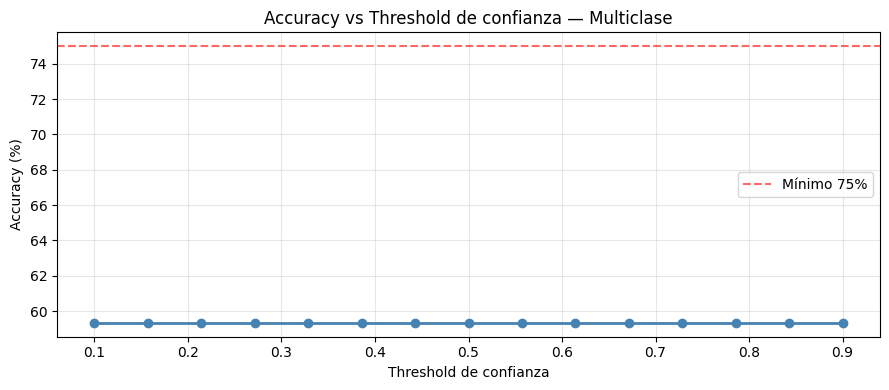

In [18]:
plt.figure(figsize=(9, 4))
plt.plot(thresholds, [a*100 for a in accuracies],
         'o-', color='steelblue', lw=2)
plt.axhline(75, color='red', linestyle='--', alpha=0.6, label='Mínimo 75%')
plt.xlabel("Threshold de confianza")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Threshold de confianza — Multiclase")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Resumen Final

In [19]:
print("=" * 58)
print("  RESUMEN MÉTRICAS — BIKE SHARING MULTICLASE")
print("=" * 58)
print(f"  Dataset:     hour.csv — {len(data):,} registros")
print(f"  Clases:      3 (Baja / Media / Alta demanda)")
print(f"  Train/Test:  75% / 25%")
print()
print(f"  Accuracy entrenamiento: {acc_train*100:.2f}%")
print(f"  Accuracy prueba:        {acc_test*100:.2f}%")
print()
print(f"  Precision (macro):      {p_macro:.4f}")
print(f"  Recall    (macro):      {r_macro:.4f}")
print(f"  F1-Score  (macro):      {f_macro:.4f}")
print()
print(f"  Precision (weighted):   {p_weighted:.4f}")
print(f"  Recall    (weighted):   {r_weighted:.4f}")
print(f"  F1-Score  (weighted):   {f_weighted:.4f}")
print("=" * 58)

  RESUMEN MÉTRICAS — BIKE SHARING MULTICLASE
  Dataset:     hour.csv — 17,379 registros
  Clases:      3 (Baja / Media / Alta demanda)
  Train/Test:  75% / 25%

  Accuracy entrenamiento: 65.11%
  Accuracy prueba:        59.33%

  Precision (macro):      0.5986
  Recall    (macro):      0.5984
  F1-Score  (macro):      0.5973

  Precision (weighted):   0.5928
  Recall    (weighted):   0.5933
  F1-Score  (weighted):   0.5918


## Conclusiones

- **Accuracy:** mide el porcentaje total de predicciones correctas en las 3 clases. Más confiable que en binario cuando las clases están balanceadas.
- **Matriz de Confusión 3×3:** muestra exactamente qué clases confunde el modelo. Los errores más frecuentes suelen ser entre clases adyacentes (Baja-Media o Media-Alta) porque sus valores de cnt están cercanos.
- **Precision por clase:** de todos los que predije como demanda alta, ¿cuántos realmente lo eran?
- **Recall por clase:** de todas las horas de demanda alta reales, ¿cuántas detecté?
- **F1-Score:** balance entre Precision y Recall. Útil para comparar clases con diferente distribución.
- **Macro vs Weighted:** macro promedia igual para todas las clases, weighted pondera por el tamaño de cada clase. Para datasets desbalanceados se prefiere weighted.